In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Datensatz einlesen

In [3]:
df = pd.read_csv('Data/employees.csv')
df.head()

,EmployeeNumber,Surname,GivenName,Gender,City,JobTitle,DepartmentName,StoreLocation,Division,Age,LengthService,AbsentHours,BusinessUnit
0,1,Gutierrez,Molly,F,Burnaby,Baker,Bakery,Burnaby,Stores,32.028816,6.018478,36.577306,Stores
1,2,Hardwick,Stephen,M,Courtenay,Baker,Bakery,Nanaimo,Stores,40.320902,5.532445,30.165072,Stores
2,3,Delgado,Chester,M,Richmond,Baker,Bakery,Richmond,Stores,48.822047,4.389973,83.807798,Stores
3,4,Simon,Irene,F,Victoria,Baker,Bakery,Victoria,Stores,44.599357,3.081736,70.020165,Stores
4,5,Delvalle,Edward,M,New Westminster,Baker,Bakery,New Westminster,Stores,35.697876,3.619091,0.000000,Stores


In [8]:
df = df[df.AbsentHours != 0]
print(df.head())

   EmployeeNumber    Surname GivenName Gender       City JobTitle  \
0               1  Gutierrez     Molly      F    Burnaby    Baker   
1               2   Hardwick   Stephen      M  Courtenay    Baker   
2               3    Delgado   Chester      M   Richmond    Baker   
3               4      Simon     Irene      F   Victoria    Baker   
5               6      Jones     Ernie      M   Richmond    Baker   

  DepartmentName StoreLocation Division        Age  LengthService  \
0         Bakery       Burnaby   Stores  32.028816       6.018478   
1         Bakery       Nanaimo   Stores  40.320902       5.532445   
2         Bakery      Richmond   Stores  48.822047       4.389973   
3         Bakery      Victoria   Stores  44.599357       3.081736   
5         Bakery      Richmond   Stores  48.440311       2.717692   

   AbsentHours BusinessUnit  
0    36.577306       Stores  
1    30.165072       Stores  
2    83.807798       Stores  
3    70.020165       Stores  
5    81.830079      

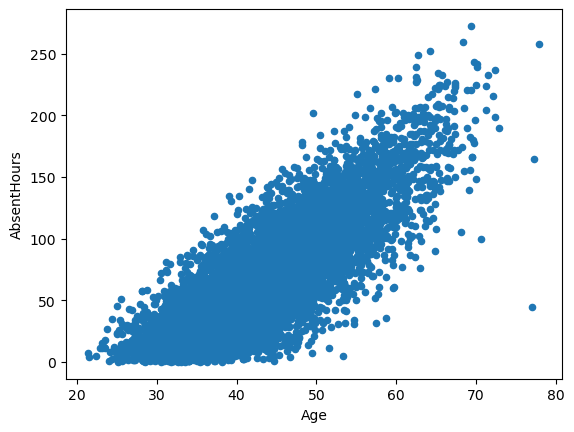

In [22]:
#Daten anzeigen
df.plot.scatter(x='Age',y='AbsentHours')
plt.show()


In [20]:
def gradient_descent(m_now, b_now, points, L, Age = 0):
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        if Age == 0:
            x = points.iloc[i].LengthService #x an name der Daten anpassen
        else:
            x = points.iloc[i].Age
        y = points.iloc[i].AbsentHours #y an Name der Daten anpassen

        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m = m_now - m_gradient * L
    b = b_now - b_gradient * L
    return m, b


1.7212804388436196 0.029210818588051492


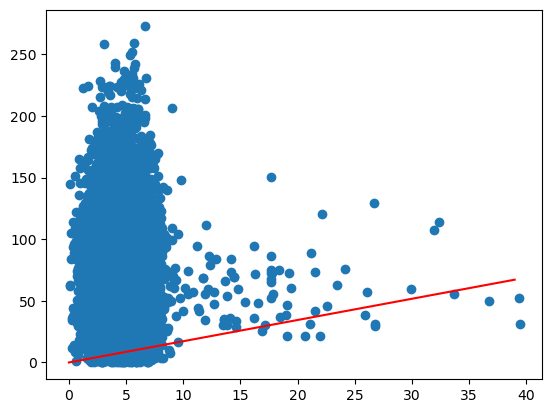

In [24]:
m = 0
b = 0
L = 0.0001
epochs = 10

for i in range(epochs):
    m, b = gradient_descent(m, b, df, L, 1)

print(m, b)

plt.scatter(y=df.AbsentHours, x=df.LengthService)
plt.plot(list(range(0, 40)), [m * x + b for x in range(0,40)], color='red')


5.240536190424372 1.1754064207337784


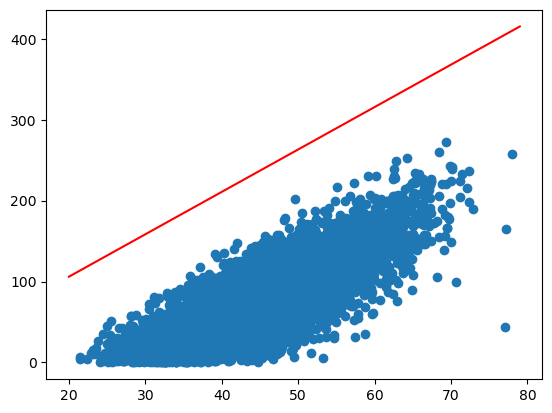

In [26]:
m = 0
b = 0
L = 0.0001
epochs = 100

for i in range(epochs):
    m, b = gradient_descent(m, b, df, L, 0)

print(m, b)

plt.scatter(y=df.AbsentHours, x=df.Age)
plt.plot(list(range(20, 80)), [m * x + b for x in range(20,80)], color='red')
